In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error

import shap

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')


Num GPUs Available:  1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
class StockIndexDataset:

    def __init__(self, file_path, target_symbol, target_column, window_size=30,
                 train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
        self.file_path = file_path
        self.target_symbol = target_symbol
        self.target_column = target_column
        self.window_size = window_size
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio
        self.scalers = {}
        self.target_col = f'{self.target_column}_{self.target_symbol}'
        
        # Load and preprocess
        self.raw_df = self._load_and_preprocess()
        self.feature_columns = [col for col in self.raw_df.columns if col != self.target_col]
        
        # Split and process
        self._train_val_test_split()
        self._fit_scalers()
        self._normalize_data()
        self._create_sequences()

    def _load_and_preprocess(self):
        df = pd.read_csv(self.file_path, parse_dates=['date'])
        pivot_df = df.pivot(index='date', columns='symbol',values=[c for c in df.columns if c not in ['date', 'symbol']])
        pivot_df.columns = [f"{col}_{sym}" for col, sym in pivot_df.columns]
        return pivot_df.sort_index().ffill()

    def _create_split_sequences(self, df):
        sequences = []
        targets = []
        
        for i in range(self.window_size, len(df)):
            seq = df[self.feature_columns].iloc[i-self.window_size:i].values
            target = df[self.target_col].iloc[i]
            sequences.append(seq)
            targets.append(target)
            
        return np.array(sequences), np.array(targets)

    def _train_val_test_split(self):
        # Time-based splitting
        n = len(self.raw_df)
        self.train_end = int(n * self.train_ratio)
        self.val_end = self.train_end + int(n * self.val_ratio)
        
        self.train_df = self.raw_df.iloc[:self.train_end]
        self.val_df = self.raw_df.iloc[self.train_end:self.val_end]
        self.test_df = self.raw_df.iloc[self.val_end:]

    def _fit_scalers(self):
        # Fit scalers on training data only
        for col in self.train_df.columns:
            self.scalers[col] = StandardScaler().fit(self.train_df[col].values.reshape(-1, 1))

    def _normalize_data(self):
        # Apply normalization to all splits
        self.train_df = self._apply_scaling(self.train_df)
        self.val_df = self._apply_scaling(self.val_df)
        self.test_df = self._apply_scaling(self.test_df)

    def _apply_scaling(self, df):
        scaled_data = np.zeros_like(df.values)
        for i, col in enumerate(df.columns):
            scaled_data[:, i] = self.scalers[col].transform(df[col].values.reshape(-1, 1)).flatten()
        return pd.DataFrame(scaled_data, index=df.index, columns=df.columns)


    # And modify _create_sequences to set these attributes
    def _create_sequences(self):
        self.X_train, self.y_train = self._create_split_sequences(self.train_df)
        self.X_val, self.y_val = self._create_split_sequences(self.val_df)
        self.X_test, self.y_test = self._create_split_sequences(self.test_df)


In [4]:
def analyze_feature_importance(dataset):
    # Flatten 3D data for tree-based models
    X_train_2d = dataset.X_train.reshape(dataset.X_train.shape[0], -1)
    feature_names = [f"{col}_t-{i}" for i in range(dataset.window_size-1, -1, -1) 
                    for col in dataset.feature_columns]

    # Train XGBoost model
    model = XGBRegressor(n_estimators=100, max_depth=5)
    model.fit(X_train_2d, dataset.y_train)

    # Permutation Importance
    result = permutation_importance(
        model, X_train_2d, dataset.y_train, n_repeats=5, random_state=42
    )
    sorted_idx = result.importances_mean.argsort()[::-1]

    print("Top 10 Features (Permutation Importance):")
    for i in sorted_idx[:10]:
        print(f"{feature_names[i]}: {result.importances_mean[i]:.4f}")

    # SHAP Analysis
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_train_2d[:1000])  # Use subset for speed
    
    shap.summary_plot(shap_values, X_train_2d[:1000], feature_names=feature_names)
    
    return model, sorted_idx

In [5]:
def train_xgboost(dataset):
    # Reshape 3D -> 2D for tree-based models
    X_train = dataset.X_train.reshape(dataset.X_train.shape[0], -1)
    X_val = dataset.X_val.reshape(dataset.X_val.shape[0], -1)
    
    model = XGBRegressor(
        n_estimators=1000,
        max_depth=7,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50
    )
    
    model.fit(
        X_train, dataset.y_train,
        eval_set=[(X_val, dataset.y_val)],
        verbose=10
    )
    
    # Evaluate
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(dataset.y_val, preds))
    print(f"Validation RMSE: {rmse:.4f}")
    
    return model

In [6]:
def create_tf_dataset(X, y, batch_size=32, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(X))
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def train_tf_lstm(dataset, patience=10, epochs=100, batch_size=32):
    # Convert data to float32 for TF
    X_train = dataset.X_train.astype('float32')
    X_val = dataset.X_val.astype('float32')
    y_train = dataset.y_train.astype('float32')
    y_val = dataset.y_val.astype('float32')

    # Create TF Datasets
    train_ds = create_tf_dataset(X_train, y_train, batch_size)
    val_ds = create_tf_dataset(X_val, y_val, batch_size)

    # Build model
    model = build_lstm_model((dataset.window_size, len(dataset.feature_columns)))

    # Callbacks
    callbacks = [
        EarlyStopping(patience=patience, restore_best_weights=True),
        ModelCheckpoint('best_lstm.h5', save_best_only=True)
    ]

    # Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model, history


In [7]:
dataset = StockIndexDataset(
    file_path='mag7.csv',
    target_symbol='QQQ',
    target_column='roc1',
    window_size=30,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)

In [10]:
dataset.raw_df.head()

,roc1_AAPL,roc1_AMZN,roc1_GOOG,roc1_META,roc1_MSFT,roc1_NFLX,roc1_NVDA,roc1_QQQ,roc20_AAPL,roc20_AMZN,...,roc50_NVDA,roc50_QQQ,roc200_AAPL,roc200_AMZN,roc200_GOOG,roc200_META,roc200_MSFT,roc200_NFLX,roc200_NVDA,roc200_QQQ
date,,,,,,,,,,,,,,,,,,,,,
2019-10-17,-0.017026,1.137273,0.809324,0.794114,-1.327968,3.201409,-1.059229,0.015505,6.480817,-1.867688,...,26.377496,5.259347,50.772700,16.135744,19.813559,40.322826,39.709985,9.597998,43.081024,25.724957
2019-10-18,0.870422,-1.120713,0.148760,-1.951988,-2.136623,-3.835410,-1.915446,-0.699341,8.579441,-2.042735,...,20.484368,2.027260,68.256402,17.145471,22.580364,41.073332,42.678526,1.511790,49.303038,28.722180
2019-10-21,2.222899,-0.101823,-0.552249,-0.330903,-0.901994,-5.215619,0.885256,-0.082655,9.962512,0.020162,...,27.256447,3.909059,64.166285,13.347166,16.385387,37.557082,37.349587,-6.559807,44.379471,24.535533
2019-10-22,1.501624,0.467702,-0.215985,-1.888620,-0.756865,-3.127492,2.687778,0.083473,10.235216,1.384927,...,29.285961,4.278206,64.156240,8.359564,16.324562,32.082592,35.133295,-15.427790,36.840412,22.090319
2019-10-23,1.110132,-1.315479,1.041612,-1.902406,-0.859649,-2.438410,-0.469357,-0.604981,10.021272,-0.348350,...,25.141377,2.238804,63.247057,6.373969,16.989082,30.604086,35.016465,-15.299591,39.961013,21.229199


Top 10 Features (Permutation Importance):
roc1_AMZN_t-0: 0.1361
roc1_NVDA_t-0: 0.1129
roc1_MSFT_t-0: 0.0562
roc1_AAPL_t-1: 0.0539
roc1_META_t-1: 0.0382
roc1_NVDA_t-1: 0.0287
roc1_META_t-0: 0.0114
roc50_AAPL_t-5: 0.0098
roc1_META_t-10: 0.0096
roc1_AAPL_t-2: 0.0084


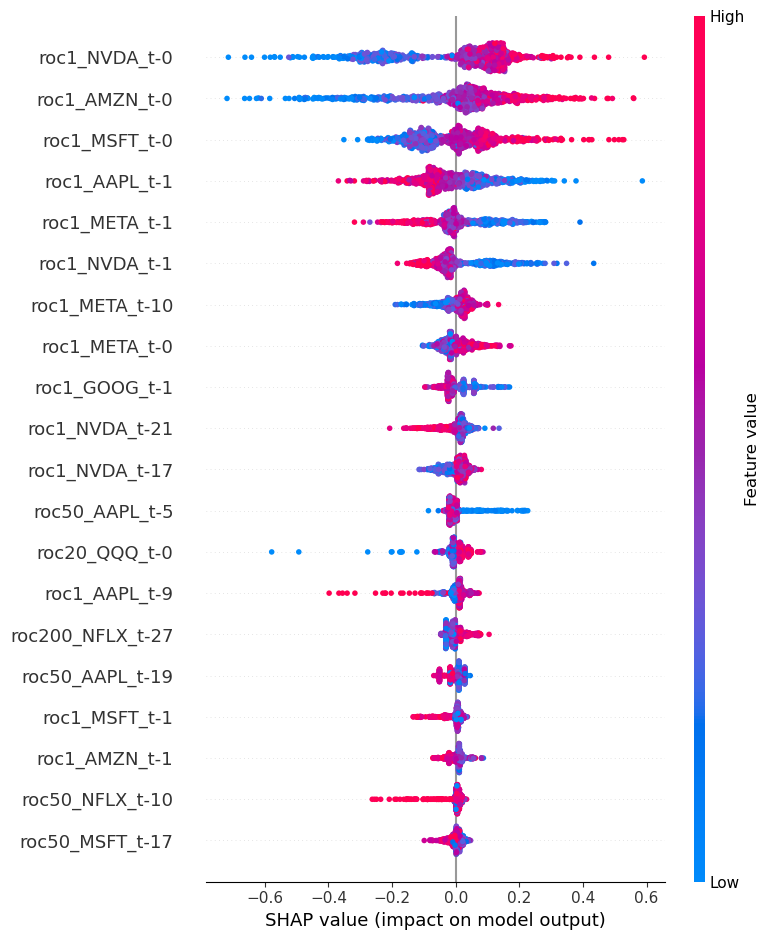

In [8]:
# Feature Importance
xgb_model, important_features = analyze_feature_importance(dataset)

In [9]:
# Train XGBoost
xgb_model = train_xgboost(dataset)

[0]	validation_0-rmse:0.76875
[10]	validation_0-rmse:0.73562
[20]	validation_0-rmse:0.70237
[30]	validation_0-rmse:0.67526
[40]	validation_0-rmse:0.65237
[50]	validation_0-rmse:0.63201
[60]	validation_0-rmse:0.61713
[70]	validation_0-rmse:0.60401
[80]	validation_0-rmse:0.59294
[90]	validation_0-rmse:0.58182
[100]	validation_0-rmse:0.57341
[110]	validation_0-rmse:0.56651
[120]	validation_0-rmse:0.55988
[130]	validation_0-rmse:0.55686
[140]	validation_0-rmse:0.55294
[150]	validation_0-rmse:0.54868
[160]	validation_0-rmse:0.54569
[170]	validation_0-rmse:0.54360
[180]	validation_0-rmse:0.54109
[190]	validation_0-rmse:0.53914
[200]	validation_0-rmse:0.53729
[210]	validation_0-rmse:0.53670
[220]	validation_0-rmse:0.53606
[230]	validation_0-rmse:0.53611
[240]	validation_0-rmse:0.53635
[250]	validation_0-rmse:0.53660
[260]	validation_0-rmse:0.53612
[270]	validation_0-rmse:0.53700
[272]	validation_0-rmse:0.53661
Validation RMSE: 0.5357


In [10]:
# Train TensorFlow model
model, history = train_tf_lstm(dataset)

# Evaluate
test_loss = model.evaluate(
    dataset.X_test.astype('float32'),
    dataset.y_test.astype('float32'),
    verbose=0
)
print(f"Test MSE: {test_loss[0]:.4f}, MAE: {test_loss[1]:.4f}")

2025-01-30 19:19:49.619902: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-01-30 19:19:49.619940: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-01-30 19:19:49.619949: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-01-30 19:19:49.619994: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-30 19:19:49.620014: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2025-01-30 19:19:50.864555: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:51.072318: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:51.150676: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:51.343699: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:51.453108: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


29/29 [==============================] - ETA: 0s - loss: 1.0577 - mae: 0.7771

2025-01-30 19:19:52.209522: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:52.284232: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-01-30 19:19:52.330384: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


29/29 [==============================] - 3s 34ms/step - loss: 1.0577 - mae: 0.7771 - val_loss: 0.4022 - val_mae: 0.5047
Epoch 2/100
 9/29 [========>.....................] - ETA: 0s - loss: 1.0922 - mae: 0.7593

You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.


29/29 [==============================] - 0s 15ms/step - loss: 0.9709 - mae: 0.7508 - val_loss: 0.4111 - val_mae: 0.5039
Epoch 3/100
29/29 [==============================] - 0s 16ms/step - loss: 0.9373 - mae: 0.7368 - val_loss: 0.4144 - val_mae: 0.5011
Epoch 4/100
29/29 [==============================] - 0s 15ms/step - loss: 0.9120 - mae: 0.7194 - val_loss: 0.4446 - val_mae: 0.5198
Epoch 5/100
29/29 [==============================] - 0s 17ms/step - loss: 0.8987 - mae: 0.7291 - val_loss: 0.4676 - val_mae: 0.5259
Epoch 6/100
29/29 [==============================] - 0s 16ms/step - loss: 0.8910 - mae: 0.7213 - val_loss: 0.3898 - val_mae: 0.4955
Epoch 7/100
29/29 [==============================] - 0s 16ms/step - loss: 0.8508 - mae: 0.7042 - val_loss: 0.4092 - val_mae: 0.5060
Epoch 8/100
29/29 [==============================] - 0s 16ms/step - loss: 0.8101 - mae: 0.6858 - val_loss: 0.4266 - val_mae: 0.5080
Epoch 9/100
29/29 [==============================] - 0s 14ms/step - loss: 0.7723 - mae: 